In [2]:
# Homework Repo Setup

# 1. ENTER your GitHub username (the one that owns your fork)
github_username ="Cipher212"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Ensure we start from /content ---
# This is crucial to prevent nested cloning/directory changes if notebook was previously run
initial_cwd = os.getcwd()
if initial_cwd != "/content":
    os.chdir("/content")
    print(f"🌍 Changed to /content from {initial_cwd}")
else:
    print(f"🌍 Already in /content.")


# --- Handle repo cloning and initial directory change ---
if os.path.exists(repo_name) and os.path.isdir(repo_name):
    # If repo exists, simply change into it from /content
    os.chdir(repo_name)
    print(f"✅ Repo '{repo_name}' already exists. Changed directory to: {os.getcwd()}")
else:
    # If repo does not exist, clone it
    print(f"📥 Cloning repo from {repo_url}...")
    os.system(f"git clone {repo_url}")
    # After cloning, change into the newly created repo directory (which is now in /content)
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found after cloning. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# --- Set Today's Directory ---
today_dir = "Assignments/HW3"
if os.path.exists(today_dir) and os.path.isdir(today_dir):
    os.chdir(today_dir)
    print(f"📂 Changed directory to: {os.getcwd()}")
else:
    print(f"❌ ERROR: Today's directory '{today_dir}' not found relative to {os.getcwd()}.")
    print(f"💡 Please ensure '{today_dir}' exists in your cloned repository.")

🌍 Already in /content.
📥 Cloning repo from https://github.com/Cipher212/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/Cipher212/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW3


# STAT 7220 - Homework 3
## Factorial Designs
## Dr. Austin Brown
## Due Date: November 21, 2025

## Part 1 Instructions:

A running shoe manufacturer wants to optimize the comfort of a new shoe model. They've identified three factors they believe will affect comfort:

| Factor | Level 1 (-) Description | Level 2 (+) Description |
|------------------------|------------------------|-------------------------|
| Sole Material (A) | Standard EVA foam | Advanced gel-infused foam |
| Insole Thickness (B) | 3mm | 6mm |
| Fabric Breathability (C) | Standard woven fabric | High-performance mesh fabric |

To evaluate the comfort of the $2^3=8$ runs, the manufacturer will recruit 3 NCAA division one cross-country athletes to test a randomly assigned shoe. Each athlete will run on a treadmill for 30 minutes in the shoes and rate the comfort on a scale of 1-10 (1 = very uncomfortable, 10 = very comfortable). The results of this experiment are contained in the `Shoe Comfort Experiment.xlsx` file. With these data, I want you to:

1.  **Briefly describe the objective of the experiment.**

Ans: To determine which combinaion of sole material, insole thickness and fabric breathability improves the overall comfort of a running shoe.

2.  **Specify the outcome variable and how it is measured.**

Ans: The outcome variable would be the comfort variable. It is measured quantitiatvely on a 1-10 scale. it is a numerical and continuous variable.

3.  **Specify the independent variables. What lurking variables may be present?**

Ans:

- sole_material (EVA or Gel)
- insole_thickness (3mm or 6mm)
- breathability (Mesh or Woven)

Lurking Variable:
- Every athlete will have a different foot shape and size, and different perception of comfort.
- Room temperature and humidity during treadmill session
- subconscious bias due to one shoe having a better visual design than the other
- Athletes testing early morning vs later in the day (prior exhaustion from wearing shoes all day)


4.  **Explain the difference between a full factorial design and a $2^k$ factorial design. Briefly comment on why the latter may be preferred in this case.**

Ans: as the name suggests, 2^k experiment design assumes 2 options (a Hi and Low or A and B) per each factor. In this case 3. Although mathematically a full factorial design would be exactly the same in this case, it will give us more information on the interactions between each factors with the fewest amount of test runs.

5.  **State the sets of null and alternative hypotheses for this experiment.**

Ans:

Sole Material

H0: No effect on comfort
H1: Effect on comfort

Insole Thickness:

H0: No effect on comfort
H1: Effect on comfort

Breathability:

H0: No effect on comfort
H1: Effect on comfort

Sole Material ~ Insole Thickness:

H0: No interaction between A and B
H1: Interaction between A and B

Sole Material ~ Breathability:

H0: No interaction between A and B
H1: Interaction between A and B

Insole Thickness ~ Breathability:

H0: No interaction between A and B
H1: Interaction between A and B


Insole Thickness ~ Breathability ~ Sole Material:

H0: No interaction between A, B and C
H1: Interaction between A, B and C

6.  **Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?**


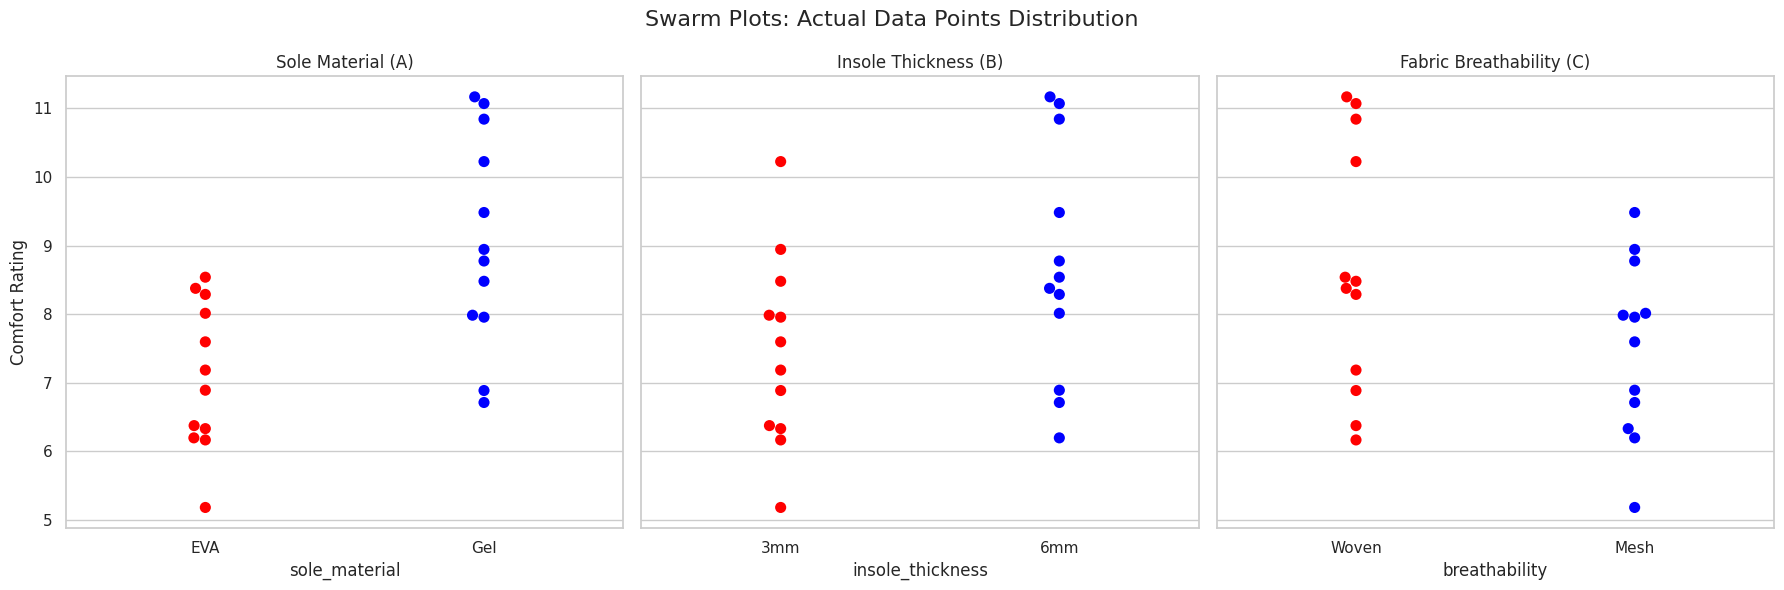

Kruskal-Wallis Test:
   H-value = 15.4667, p-value = 0.0305


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols







# load df
df = pd.read_excel('Shoe Comfort Experiment.xlsx')

#theme
sns.set_theme(style="whitegrid")
custom_colors = ['red', 'blue']

# categorical scatter plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Swarm Plots: Actual Data Points Distribution', fontsize=16)

sns.swarmplot(ax=axes[0], data=df, x='sole_material', y='comfort', hue='sole_material', legend=False, palette=custom_colors, size=8)
axes[0].set_title('Sole Material (A)')
axes[0].set_ylabel('Comfort Rating')

sns.swarmplot(ax=axes[1], data=df, x='insole_thickness', y='comfort', hue='insole_thickness', legend=False, palette=custom_colors, size=8)
axes[1].set_title('Insole Thickness (B)')
axes[1].set_ylabel('')

sns.swarmplot(ax=axes[2], data=df, x='breathability', y='comfort', hue='breathability', legend=False, palette=custom_colors, size=8)
axes[2].set_title('Fabric Breathability (C)')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()



# Kruskal wallis test

df_sorted = df.sort_values(['sole_material', 'insole_thickness', 'breathability'])

groups = np.split(df_sorted['comfort'].values, 8)
kw_stat, kw_pval = stats.kruskal(*groups)

print(f"Kruskal-Wallis Test:")
print(f"   H-value = {kw_stat:.4f}, p-value = {kw_pval:.4f}")



Observation:


Kruskal Wallis ($p = 0.03$) supports assumption that different shoe combinations will have different comfort ratings. Data shows that Gel Foam is on average more comfortable than EVA and 6mm insoles perform better than 3mm insoles. Woven Fabric appears higher rated than Mesh fabric.

Overall, EDA is supporting our H1 (Alternative) Hypothesis more.

7.  Fit a full factorial ANOVA model to the data. Assess the normality assumption using both a visual method and a testing method. Do we have evidence to support the assumption of normality? Why or why not?


<Figure size 800x600 with 0 Axes>

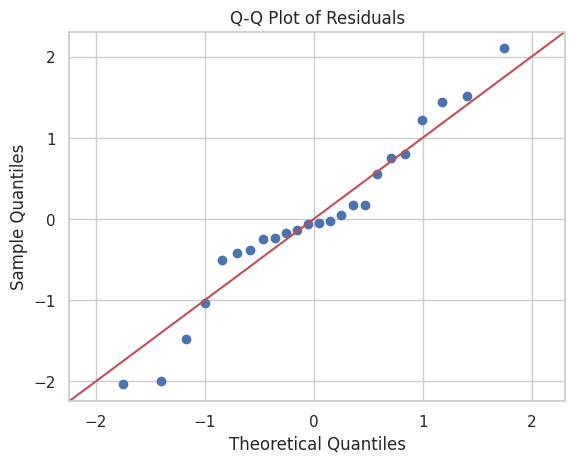

Shapiro-Wilke Statistic=0.9595, p-value=0.4291


In [4]:
## Question 7 Code ##

# model
model = ols('comfort ~ C(sole_material) * C(insole_thickness) * C(breathability)', data=df).fit()

residuals = model.resid

# Shaprio Wilke
shapiro_stat, shapiro_p = stats.shapiro(residuals)


# QQ PLOT
plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.show()

print(f"Shapiro-Wilke Statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")


8.  Assess the constant variance assumption using both a visual method and a testing method. Do we have evidence to support the assumption of constant variance? Why or why not?


Observation:

Yes, both the testing and visual methods support the assumption of normality for the ANOVA model.

The Shapiro-Wilk test produced non-significant p-value ($0.4291$), mathematically confirming that the residuals do not differ from a normal distribution.

 On the other hand, qqplot does show deviations at tail and waviness, this can be attributed to a small sample size ($N=24$) and does not imply any skew ness. So the normality assumption is still being satsified

[link text](https://)
9.  Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects? Our two-way interactions? Our three-way interaction?


In [5]:
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                                                       sum_sq    df  \
C(sole_material)                                    22.814025   1.0   
C(insole_thickness)                                  9.439657   1.0   
C(breathability)                                     7.645101   1.0   
C(sole_material):C(insole_thickness)                 0.000485   1.0   
C(sole_material):C(breathability)                    0.700584   1.0   
C(insole_thickness):C(breathability)                 4.949082   1.0   
C(sole_material):C(insole_thickness):C(breathab...   0.641055   1.0   
Residual                                            15.630245  16.0   

                                                            F    PR(>F)  
C(sole_material)                                    23.353723  0.000184  
C(insole_thickness)                                  9.662965  0.006758  
C(breathability)                                     7.825956  0.012908  
C(sole_material):C(insole_thickness)                 0.000496  0

Observaiton:

Regarding main effects, we reject all null hypothesis from the sets. Changing the sole material, insole thickness, or fabric breathability each  causes a statistically significant change in the comfort rating. However only Sole Material acts independently.

Two-Way interactions are however non-significant except for InSole Thickness x Breathability.

For the three way interaction, we fail to reject the  (H0) null hypothesis here. The 3 way interaction of all factors in this dataset does not create an effect beyond what is explained by the main effects and the significant two-way interaction.

Overall, although nott all terms within the model are significant, but it can still be interpreted.


10. Calculate and interpret the partial $\eta^2$ values for each of the main effects and interactions. Which effects and/or interactions are most important? Why?


In [14]:
# 1. Grab the Residual Sum of Squares
ss_residual = anova_table.loc['Residual', 'sum_sq']

# 2. Calculate Partial Eta-Squared for the entire column at once
anova_table['partial_eta_sq'] = anova_table['sum_sq'] / (anova_table['sum_sq'] + ss_residual)

# 3. Simply drop the 'Residual' row from the final display, since it doesn't need an effect size
partial_table = anova_table.drop('Residual')

# View the final clean table!
print(partial_table['partial_eta_sq'])

C(sole_material)                                         0.593431
C(insole_thickness)                                      0.376533
C(breathability)                                         0.328463
C(sole_material):C(insole_thickness)                     0.000031
C(sole_material):C(breathability)                        0.042899
C(insole_thickness):C(breathability)                     0.240488
C(sole_material):C(insole_thickness):C(breathability)    0.039398
Name: partial_eta_sq, dtype: float64


INtepretation:

Regarding the main effects, we reject the null hypotheses for all three sets. however, only Sole Material acts independently, proving to be the major factor overall ($ = 0.5934$).

Because there is a statistically  significant 2 -way interaction between Insole Thickness and Breathability ($= 0.2405$), their large main effects cannot be interpreted alone. The comfort of the thickness depends heavily on the fabric paired with it.

 All other two-way interactions are non-significant. We also fail to reject the null hypothesis for the 3 -way interaction.

 Overall, while not all terms within the model are significant, the factors that are significant drive massive real-world effects on shoe comfort.




11. Summarize your conclusions. Which combination of factors would you recommend to the shoe manufacturer? Why?


**Ans:**

The factorial experiment showed that Sole Material is the main independent driver for running shoe comfort ratings with partial eta ($ = 0.59$). This means that using Gel instead of EVA provides a statistically significant benefit.

Insole Thickness and Fabric Breathability are also strong influence, but their 2 way interaction was statistically significant, which means either cannot be interpreted independendly, hence the effectiveness of both factors depend on what it is paired with.

Based on this analaysis, I would recommend the manufacturer to make Gel-infused foam shoes with 6mm insole and Woven type frbaic. statistically this would give the highest overall comfort ratings.




## PART 2 INSTRUCTIONS:
The same company is interested in developing a new GPS-enabled fitness band for runners. They want to maximize user satisfaction and have identified three key factors:

| Run | GPS Accuracy (A) | Battery Life (B) | Display (C) |
|-----|------------------|------------------|-------------|
| 1   | \- (Standard)    | \- (6 hours)     | \- (Small)  |
| 2   | \+ (High)        | \- (6 hours)     | \+ (Large)  |
| 3   | \- (Standard)    | \+ (12 hours)    | \+ (Large)  |
| 4   | \+ (High)        | \+ (12 hours)    | \- (Small)  |

Due to time and resource limitations, the company would rather conduct a $2^{3-1}$ fractional factorial experiment. For each of the above runs, the company will recruit 3 NCAA division one cross-country athletes to test a randomly assigned fitness band. Each athlete will use the band for one month during their competition season. At the end of the month, the athletes will be asked to rate their level of satisfaction on a scale of 1-10 (1 = very dissatisfied, 10 = very satisfied). The results of this experiment are contained in the `Fitness Band Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

Ans: To confirm which combination of GPS Accuracy, Battery Life, and Display size maximizes user satisfaction.

2.  Specify the outcome variable and how it is measured.

Ans: User satisfaction. Which is measured on a  scale of 1 to 10 with a time period of 1 month.

3.  Specify the independent variables. What lurking variables may be present?

Ans:  GPS Accuracy, Battery Life and Display Size.  
Lurking variables could be:

Wrist Size, Test Phone (or each user having their own phone), environmental conditions, running location and time, user habits, charging habits, physical stress from the training itself


4.  Explain the difference between a full $2^k$ factorial design and a $2^{3-1}$ fractional factorial design. Briefly comment on why the latter may be preferred in this case.

Ans:  The Full 2^3 factorial design would test all of the 8 possible factor combinations, which would allow us to observe all main effects + 2 way and 3 way interactions. The 2^3-1 fractional design would bring us down to 4 combinations that include the main effect and the 2 way interactions.

For this case it would be preferred as it reduces the number of athletes which would cost time and money to hire and collect data with but would still allow us to interpret the main effects.

5.  State the sets of null and alternative hypotheses for this experiment.

6.  Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

7.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


In [6]:

## Question 7 Code ##


8.  Fit the appropriate ANOVA model to the data. Assess the normality assumption using both a testing method and a visual method. Do we have evidence to support the assumption of normality? Why or why not?


In [7]:
## Question 8 Code ##


9.  Assess the constant variance assumption using both a testing method and a visual method. Do we have evidence to support the assumption of constant variance? Why or why not?


In [8]:
## Question 9 Code ##

10. Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects?

In [9]:
## Question 10 Code ##

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [10]:
## Question 11 Code ##

12. Calculate and interpret the partial $\eta^2$ values for each of the main effects. Which effects are most important? Why?

In [11]:
## Question 12 Code ##

13. Summarize your conclusions. Which combination of factors would you recommend to the fitness band manufacturer? Why?